### 부스팅(Boosting)

### 라이브러리 설치
- pip install xgboost
- pip install lightgbm

In [1]:
# 기본
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 뜨지 않게 설정
import warnings
warnings.filterwarnings('ignore')

# 그래프 설정
sns.set()

# 그래프 기본 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
# plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['figure.figsize'] = 12, 6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False


# 데이터 전처리 알고리즘
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# 학습용과 검증용으로 나누는 함수
from sklearn.model_selection import train_test_split

# 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold

# 평가함수
# 분류용
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

# 모델의 최적의 하이퍼 파라미터를 찾기 위한 도구
from sklearn.model_selection import GridSearchCV

# 머신러닝 알고리즘 - 분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 혼동행렬 확인 
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 피처중요도 확인 
import shap
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb

import os
import joblib


### 분류

In [ ]:
# 데이터 준비
df1 = pd.read_csv("./result/AB_top7.csv")

# 입력과 결과로 나눈다.
X = df1.drop('Segment', axis=1)
y = df1['Segment']

# 문자열 -> 숫자
encoder1 = LabelEncoder()
encoder1.fit(y)
y2 = encoder1.transform(y)

# 입력 데이터 표준화
scaler1 = StandardScaler()
scaler1.fit(X)
X2 = scaler1.transform(X)

# 학습용과 검증용으로 나눈다.
train_X, test_X, train_y, test_y = train_test_split(X2, y2, test_size=0.2, random_state=1)

In [5]:
feature_names = df1.drop(columns=['Segment']).columns.tolist()
feature_names

['카드이용한도금액',
 'CA한도금액',
 '이용건수_선결제_R3M',
 '선입금원금_B2M',
 '상환개월수_결제일_R3M',
 '선입금원금_B5M',
 '이용개월수_결제일_R6M']

### 기본 모델 사용하기

In [3]:
model1 = AdaBoostClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model1, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7041533296569533


In [4]:
model2 = GradientBoostingClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model2, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7361405570693496


In [5]:
model3 = LGBMClassifier(verbose=-1)

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model3, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7450196078431371


In [7]:
model4 = XGBClassifier()

# 교차 검증
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
r1 = cross_val_score(model4, train_X, train_y, scoring='f1', cv=kfold)
print(f'평균 f1 Score : {r1.mean()}')

평균 f1 Score : 0.7516666800691568


### 모델 하이퍼 파라미터 튜닝

In [ ]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도

params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model1 = AdaBoostClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf = GridSearchCV(model1, param_grid=params, scoring='f1', cv=kfold)
grid_clf.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 150}
최적의 모델 평균 성능 : 0.7133237501232857


In [48]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model2 = GradientBoostingClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf2 = GridSearchCV(model2, param_grid=params, scoring='f1', cv=kfold)
grid_clf2.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf2.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf2.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 50}
최적의 모델 평균 성능 : 0.7568280177568103


In [49]:
# 튜닝할 하이퍼 파라미터 후보 값
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model3 = LGBMClassifier(verbose=-1)
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf3 = GridSearchCV(model3, param_grid=params, scoring='f1', cv=kfold)
grid_clf3.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf3.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf3.best_score_}')

최적의 하이퍼 파라미터 : {'learning_rate': 0.1, 'n_estimators': 50}
최적의 모델 평균 성능 : 0.7673411810068157


In [11]:
# 튜닝할 하이퍼 파라미터 후보 값
# booster : 내부에서 사용할 알고리즘. gbtree - 결정트리, gblinear - 선형모델
# n_estimators : 트리의 개수
# learning_rate : 학습률. 오차 보정을 위해 상수 값들을 수정하는 정도
params = {
    'booster' : ['gbtree', 'gblinear'],
    'n_estimators' : [50, 100, 150, 200, 250, 300],
    'learning_rate' : [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}
# 사용할 모델 객체를 생성한다.
model4 = XGBClassifier()
# 최적의 하이퍼 파라미터를 찾는다.
kfold = KFold(n_splits=10, shuffle=True, random_state=1)
grid_clf4 = GridSearchCV(model4, param_grid=params, scoring='f1', cv=kfold)
grid_clf4.fit(train_X, train_y)
print(f'최적의 하이퍼 파라미터 : {grid_clf4.best_params_}')
print(f'최적의 모델 평균 성능 : {grid_clf4.best_score_}')

최적의 하이퍼 파라미터 : {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 150}
최적의 모델 평균 성능 : 0.7593057778135177


### 250708 하이퍼 파라미터 튜닝

In [6]:
# 저장 디렉토리 생성
os.makedirs("./model/A_B", exist_ok=True)

# 공통 하이퍼파라미터
common_params = {
    'n_estimators': [50, 100, 150, 200, 250, 300],
    'learning_rate': [0.0001, 0.001, 0.01, 0.1, 1, 0, 10, 100, 1000, 10000]
}

# XGBoost 전용 파라미터 (GPU에서 gblinear 미지원)
xgb_params = {
    **common_params,
    'booster': ['gbtree']
}

# 모델 리스트 (GPU 사용 포함)
models = [
    ("GradientBoosting", GradientBoostingClassifier(), common_params),
    ("AdaBoost", AdaBoostClassifier(), common_params),
    ("LightGBM", LGBMClassifier(device='gpu', verbose=-1), common_params),
    ("XGBoost", XGBClassifier(
        verbosity=0,
        use_label_encoder=False,
        tree_method='gpu_hist',
        predictor='gpu_predictor'
    ), xgb_params),
]

results = []
grid_models = {}  # 학습된 GridSearchCV 객체 저장용
kfold = KFold(n_splits=10, shuffle=True, random_state=1)

# 모델별 학습 및 저장
for name, model, param_grid in models:
    print(f"\n[{name}] GridSearchCV 시작 중...")

    grid = GridSearchCV(model, param_grid=param_grid, scoring='f1', cv=kfold, n_jobs=-1)
    grid.fit(train_X, train_y)

    # 객체 저장
    grid_models[name] = grid
    # 객체 저장
    joblib.dump({
        "model": grid,
        "features": feature_names
    }, f"./model/A_B/{name}_gridsearch_model.pkl")


    # 최적 결과 저장
    results.append({
        "model": name,
        "best_params": grid.best_params_,
        "best_score": grid.best_score_
    })

    print(f"[{name}] 최적 파라미터: {grid.best_params_}")
    print(f"[{name}] 평균 F1 성능: {grid.best_score_:.4f}")

    # 전체 결과 저장
    result_df = pd.DataFrame(grid.cv_results_).sort_values(by='mean_test_score', ascending=False)
    result_df.to_csv(f"./model/A_B/{name}_gridsearch_results.csv", index=False)
    print(f"[{name}] 결과 CSV 저장 완료: ./model/A_B/{name}_gridsearch_results.csv")

# 전체 요약 저장
results_df = pd.DataFrame(results)
results_df.to_csv("./model/A_B/model_tuning_results.csv", index=False)
print("\n 전체 모델 요약 저장 완료: ./model/A_B/model_tuning_results.csv")


[GradientBoosting] GridSearchCV 시작 중...
[GradientBoosting] 최적 파라미터: {'learning_rate': 0.1, 'n_estimators': 50}
[GradientBoosting] 평균 F1 성능: 0.7568
[GradientBoosting] 결과 CSV 저장 완료: ./model/A_B/GradientBoosting_gridsearch_results.csv

[AdaBoost] GridSearchCV 시작 중...
[AdaBoost] 최적 파라미터: {'learning_rate': 0.1, 'n_estimators': 150}
[AdaBoost] 평균 F1 성능: 0.7133
[AdaBoost] 결과 CSV 저장 완료: ./model/A_B/AdaBoost_gridsearch_results.csv

[LightGBM] GridSearchCV 시작 중...
[LightGBM] 최적 파라미터: {'learning_rate': 0.1, 'n_estimators': 50}
[LightGBM] 평균 F1 성능: 0.7683
[LightGBM] 결과 CSV 저장 완료: ./model/A_B/LightGBM_gridsearch_results.csv

[XGBoost] GridSearchCV 시작 중...
[XGBoost] 최적 파라미터: {'booster': 'gbtree', 'learning_rate': 0.1, 'n_estimators': 100}
[XGBoost] 평균 F1 성능: 0.7638
[XGBoost] 결과 CSV 저장 완료: ./model/A_B/XGBoost_gridsearch_results.csv

 전체 모델 요약 저장 완료: ./model/A_B/model_tuning_results.csv


### GradientBoosting 피처중요도 확인

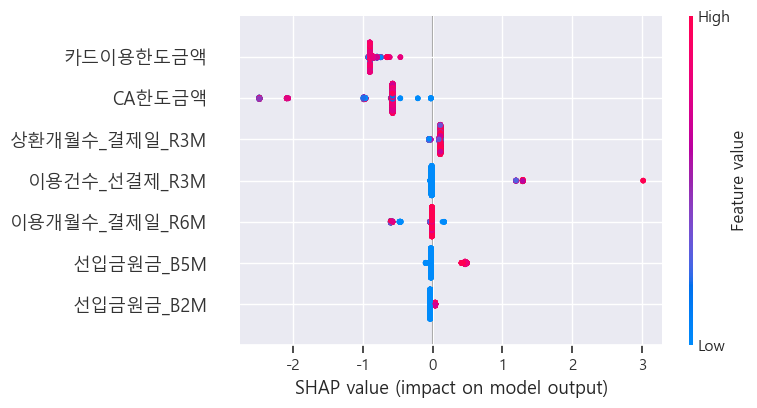

         feature  importance
0       카드이용한도금액    0.420905
1         CA한도금액    0.339192
6  이용개월수_결제일_R6M    0.075471
3      선입금원금_B2M    0.072830
2   이용건수_선결제_R3M    0.063808
5      선입금원금_B5M    0.019922
4  상환개월수_결제일_R3M    0.007872


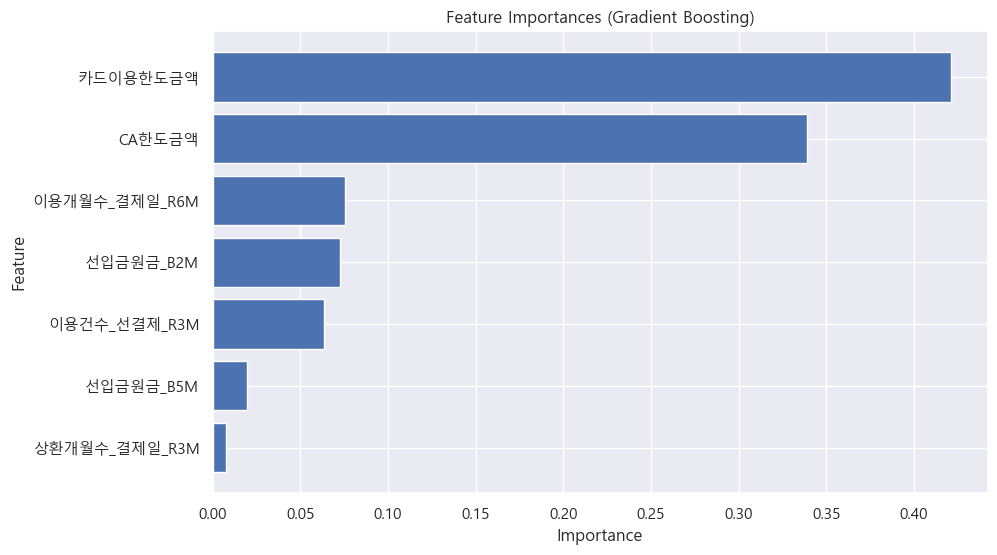

In [ ]:
# 최종 모델 지정 (GridSearchCV 사용한 경우)
final_model = grid_clf2.best_estimator_

# SHAP용 TreeExplainer 생성
explainer = shap.Explainer(final_model)  # sklearn 모델은 이렇게 생성

# 원래 데이터에서 샘플링 (해석력 보존)
X_df_original = pd.DataFrame(X, columns=df1.drop('Segment', axis=1).columns)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

# SHAP 값 계산 및 시각화
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample)
plt.show()

# 중요도 추출 (GradientBoostingClassifier는 feature_importances_ 사용)
importances = final_model.feature_importances_

# 컬럼 이름 가져오기
feature_names = df1.drop('Segment', axis=1).columns.tolist()

# DataFrame 생성 및 정렬
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
})
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 출력
print(importance_df.head(7))

# 막대 그래프 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importances (Gradient Boosting)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### XG부스트 피처중요도 확인

In [82]:
# 최종 모델 지정
final_model = grid_clf4.best_estimator_

# TreeExplainer 객체 생성
explainer = shap.TreeExplainer(final_model)

# 검증 데이터에서 3만 개 샘플링 (test_X는 이미 표준화된 형태)
# → 원래 X에서 샘플링하는 게 더 해석력 높음 (스케일 전)
X_df_original = pd.DataFrame(X, columns=df1.drop('Segment', axis=1).columns)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

# 샘플 데이터에 대한 SHAP 값 계산
shap_values = explainer.shap_values(X_sample)

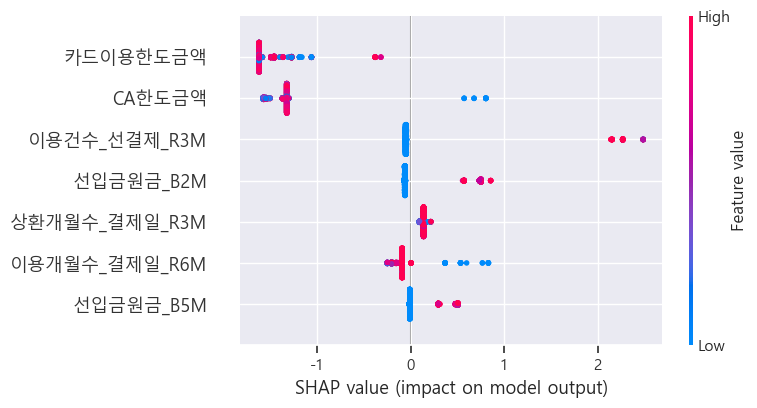

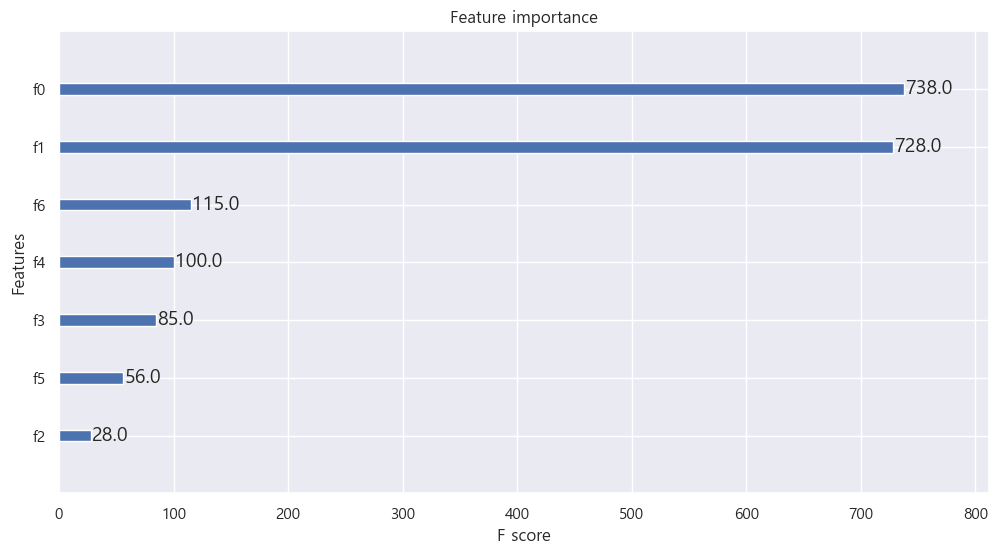

In [84]:
# SHAP 요약 플롯 그리기
shap.summary_plot(shap_values, X_sample)
plt.show()

# 중요도 시각화 (XGBoost 내장)
xgb.plot_importance(final_model)
plt.show()

In [76]:
# 3가지 지원하지만 그중 'gain'이 가장 의미 있는 기준
# gain은 예측 성능에 가장 크게 기여한 피처 파악 가능함, 해당 피처를 사용해 얻은 정보 이득의 평균

# 중요도 딕셔너리 추출
importance_dict = final_model.get_booster().get_score(importance_type='gain')

# DataFrame 먼저 생성
importance_df = pd.DataFrame(importance_dict.items(), columns=['feature', 'importance'])

# 컬럼 이름 리스트 만들기
feature_names = df1.drop('Segment', axis=1).columns.tolist()

# f0 → 실제 컬럼명으로 매핑
mapping = {f"f{i}": name for i, name in enumerate(feature_names)}
importance_df['feature'] = importance_df['feature'].map(mapping)

# 중요도 기준 정렬
importance_df = importance_df.sort_values(by='importance', ascending=False)

# 결과 출력
print(importance_df.head(7))

         feature  importance
2   이용건수_선결제_R3M    4.208557
6  이용개월수_결제일_R6M    2.270796
1         CA한도금액    1.758904
0       카드이용한도금액    1.354626
3      선입금원금_B2M    1.226646
4  상환개월수_결제일_R3M    0.805506
5      선입금원금_B5M    0.618609


### 피처중요도 확인

#####  1. SHAP 분석용 데이터 준비

In [25]:
# X: 전체 피처 데이터, df1에서 Segment 컬럼 제거한 형태
feature_names = df1.drop('Segment', axis=1).columns.tolist()

X_df_original = pd.DataFrame(X, columns=feature_names)
X_sample = X_df_original.sample(n=min(30000, len(X_df_original)), random_state=42)

##### 2. 시각화 함수

In [33]:
def shap_analysis(model, model_name, X_sample, feature_names, save_dir="./model/A_B"):
    print(f"\n[SHAP 분석 시작] {model_name}")

    try:
        # 모델별 explainer 방식
        if model_name == "LightGBM":
            explainer = shap.Explainer(model.booster_)
        elif model_name in ["GradientBoosting", "XGBoost"]:
            explainer = shap.TreeExplainer(model)
        elif model_name == "AdaBoost":
            raise NotImplementedError("AdaBoostClassifier는 SHAP을 지원하지 않습니다.")
        else:
            explainer = shap.Explainer(model)

        # SHAP 값 계산
        shap_values = explainer(X_sample)

        # SHAP Summary Plot 저장
        shap.summary_plot(shap_values, X_sample, show=False)
        plt.title(f"SHAP Summary - {model_name}")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/shap_summary_{model_name}.png")
        plt.show()

    except Exception as e:
        print(f"[SHAP 생략] {model_name}: {e}")

    # Feature Importance 시각화 (가능한 경우)
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        }).sort_values(by='importance', ascending=False)

        print(f"[Feature Importance - {model_name}] 상위 7개")
        print(importance_df.head(7))

        plt.figure(figsize=(10, 6))
        plt.barh(importance_df['feature'], importance_df['importance'])
        plt.gca().invert_yaxis()
        plt.title(f"Feature Importances - {model_name}")
        plt.xlabel("Importance")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(f"{save_dir}/feature_importance_{model_name}.png")
        plt.show()


모델 로딩 중: AdaBoost

[SHAP 분석 시작] AdaBoost
[SHAP 생략] AdaBoost: AdaBoostClassifier는 SHAP을 지원하지 않습니다.
[Feature Importance - AdaBoost] 상위 7개
         feature  importance
0       카드이용한도금액    0.413333
1         CA한도금액    0.193333
4  상환개월수_결제일_R3M    0.160000
2   이용건수_선결제_R3M    0.086667
3      선입금원금_B2M    0.080000
5      선입금원금_B5M    0.066667
6  이용개월수_결제일_R6M    0.000000


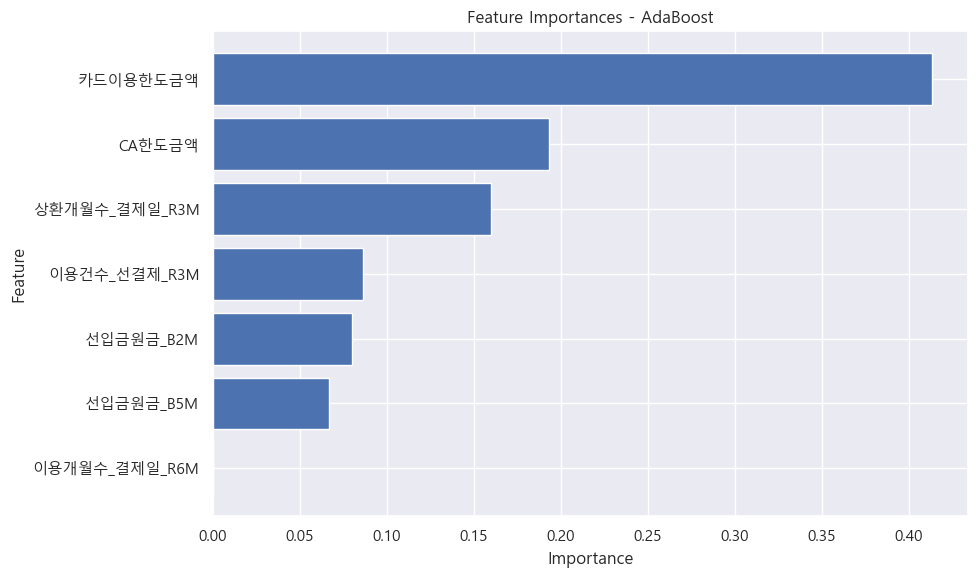


모델 로딩 중: GradientBoosting

[SHAP 분석 시작] GradientBoosting


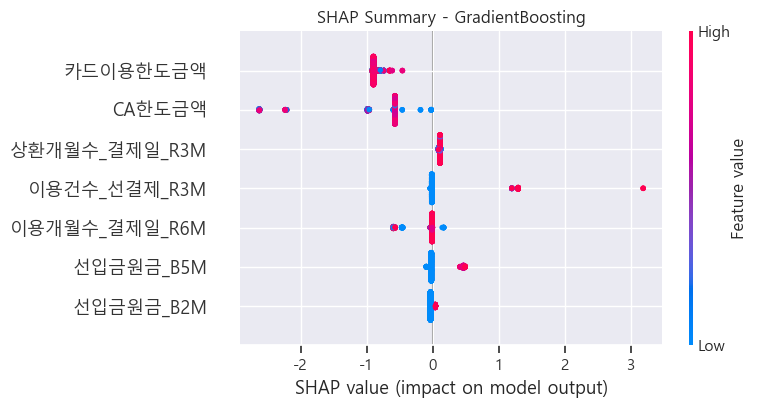

[Feature Importance - GradientBoosting] 상위 7개
         feature  importance
0       카드이용한도금액    0.420889
1         CA한도금액    0.340026
6  이용개월수_결제일_R6M    0.075602
3      선입금원금_B2M    0.071731
2   이용건수_선결제_R3M    0.063963
5      선입금원금_B5M    0.019328
4  상환개월수_결제일_R3M    0.008460


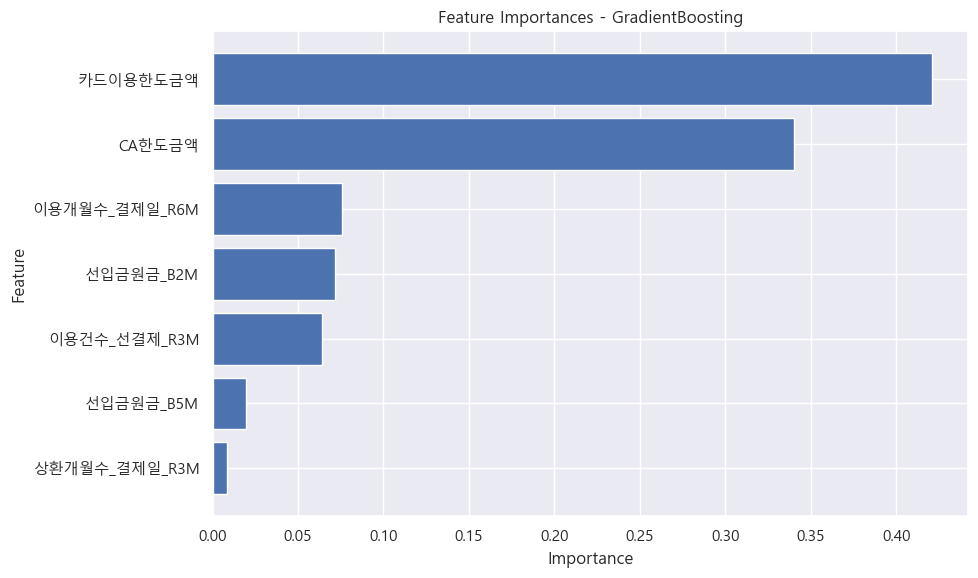


모델 로딩 중: LightGBM

[SHAP 분석 시작] LightGBM


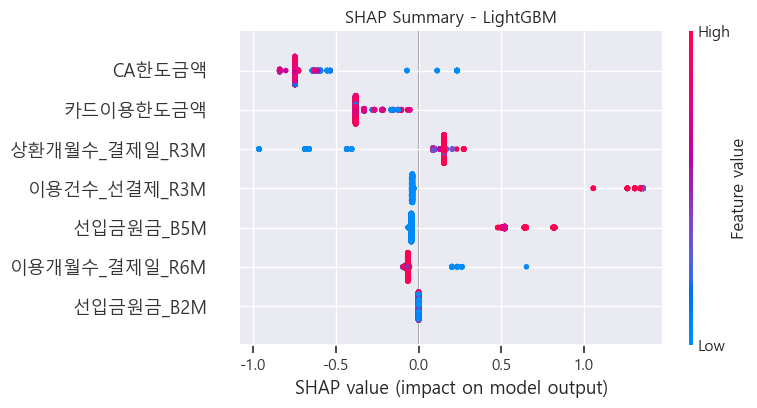

[Feature Importance - LightGBM] 상위 7개
         feature  importance
1         CA한도금액        2988
0       카드이용한도금액        2787
6  이용개월수_결제일_R6M         685
4  상환개월수_결제일_R3M         444
5      선입금원금_B5M         443
2   이용건수_선결제_R3M         148
3      선입금원금_B2M           0


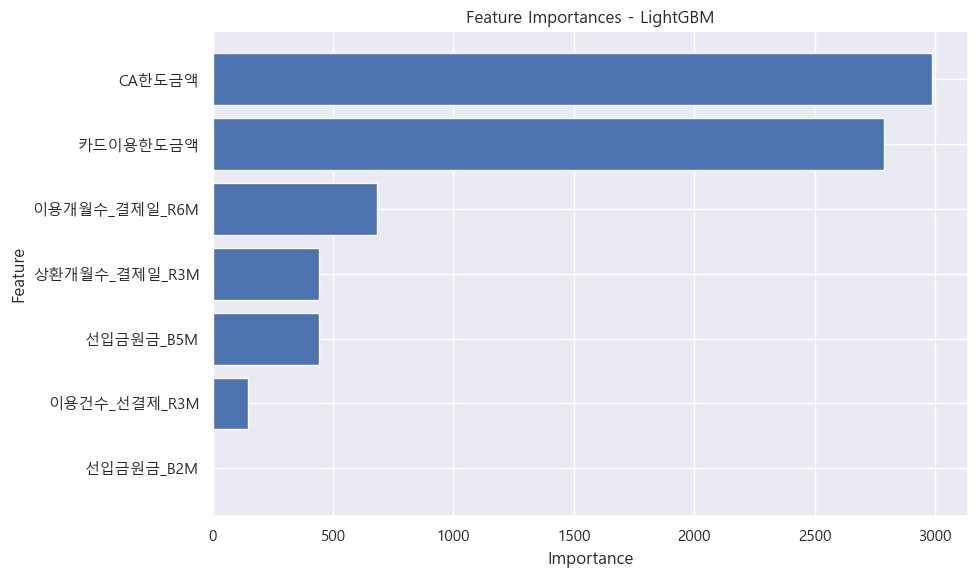


모델 로딩 중: XGBoost

[SHAP 분석 시작] XGBoost


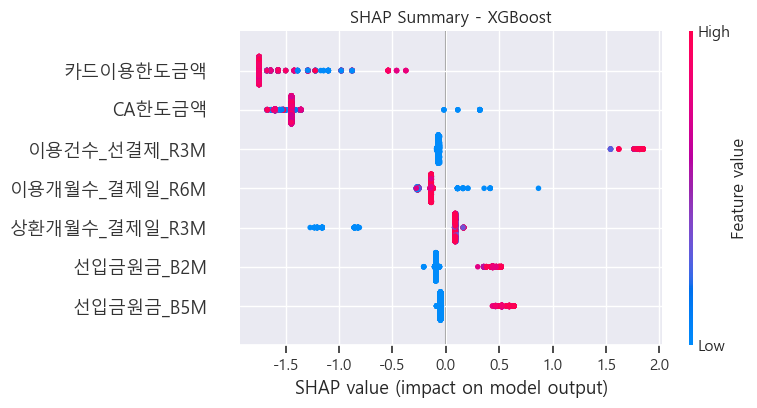

[Feature Importance - XGBoost] 상위 7개
         feature  importance
1         CA한도금액    0.226476
2   이용건수_선결제_R3M    0.194732
6  이용개월수_결제일_R6M    0.181580
0       카드이용한도금액    0.124706
4  상환개월수_결제일_R3M    0.104642
5      선입금원금_B5M    0.085022
3      선입금원금_B2M    0.082842


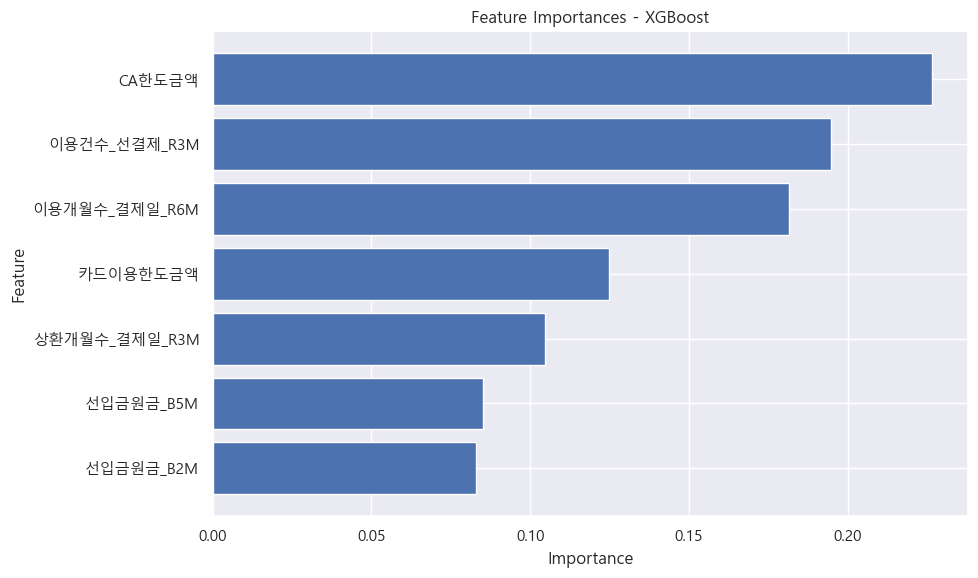

In [34]:
model_names = ["AdaBoost", "GradientBoosting", "LightGBM", "XGBoost"]

for name in model_names:
    print(f"\n모델 로딩 중: {name}")
    model = joblib.load(f"./model/A_B/{name}_gridsearch_model.pkl").best_estimator_
    shap_analysis(model, name, X_sample, feature_names)

### PDF

In [37]:
from matplotlib.backends.backend_pdf import PdfPages
from PIL import Image
import ast

# 설정
model_names = ["AdaBoost", "GradientBoosting", "LightGBM", "XGBoost"]
base_dir = "./model/A_B"
pdf_path = f"{base_dir}/model_report.pdf"
csv_path = f"{base_dir}/model_tuning_results.csv"

# CSV에서 최적 파라미터 불러오기
params_df = pd.read_csv(csv_path).set_index("model")

# PDF 생성
with PdfPages(pdf_path) as pdf:
    for name in model_names:
        print(f"\n{name} 모델 요약 페이지 생성 중...")

        # 최적 파라미터 파싱
        best_params = params_df.loc[name, "best_params"]
        if isinstance(best_params, str):
            try:
                best_params = ast.literal_eval(best_params)
            except Exception:
                best_params = {"파라미터 파싱 실패": best_params}

        param_text = "\n".join([f"- {k}: {v}" for k, v in best_params.items()])

        # 요약 텍스트 페이지
        plt.figure(figsize=(10, 3))
        plt.axis('off')
        plt.title(f"모델: {name}", fontsize=16, loc='left')
        plt.text(0, 0.7, "최적 하이퍼파라미터", fontsize=13, fontweight='bold')
        plt.text(0, 0.4, param_text, fontsize=12)
        pdf.savefig()
        plt.close()

        # 시각화 이미지 삽입 (SHAP + feature importance)
        for plot_type in ["shap_summary", "feature_importance"]:
            img_path = f"{base_dir}/{plot_type}_{name}.png"
            if os.path.exists(img_path):
                image = Image.open(img_path)
                plt.figure(figsize=(12, 6))
                plt.imshow(image)
                plt.axis('off')
                plt.title(f"{plot_type.replace('_', ' ').title()} - {name}")
                pdf.savefig()
                plt.close()

print(f"\n모델 리포트 PDF 저장 완료: {pdf_path}")


AdaBoost 모델 요약 페이지 생성 중...

GradientBoosting 모델 요약 페이지 생성 중...

LightGBM 모델 요약 페이지 생성 중...

XGBoost 모델 요약 페이지 생성 중...

모델 리포트 PDF 저장 완료: ./model/A_B/model_report.pdf


### 학습한 데이터를 통해 검증을 한다

In [39]:
def plot_confusion_matrix(y_true, y_pred, model_name, labels=[0, 1]):
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()


[검증 평가] AdaBoost 모델
Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       199
           1       0.81      0.68      0.74        25

    accuracy                           0.95       224
   macro avg       0.89      0.83      0.85       224
weighted avg       0.94      0.95      0.94       224



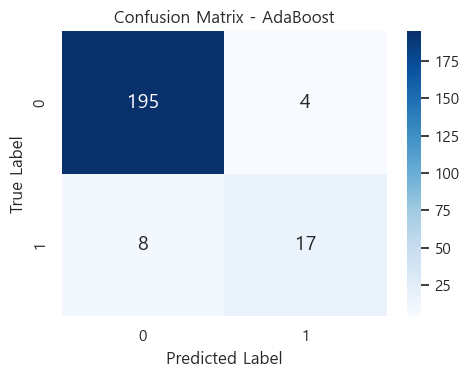


[검증 평가] GradientBoosting 모델
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.87      0.80      0.83        25

    accuracy                           0.96       224
   macro avg       0.92      0.89      0.91       224
weighted avg       0.96      0.96      0.96       224



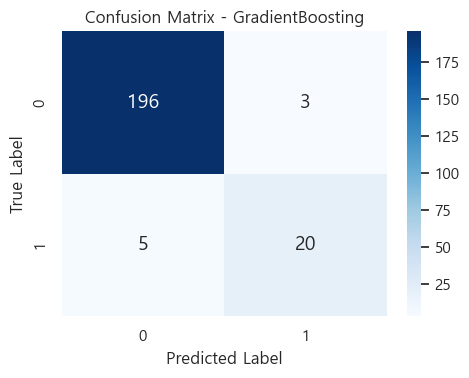


[검증 평가] LightGBM 모델
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       199
           1       0.82      0.72      0.77        25

    accuracy                           0.95       224
   macro avg       0.89      0.85      0.87       224
weighted avg       0.95      0.95      0.95       224



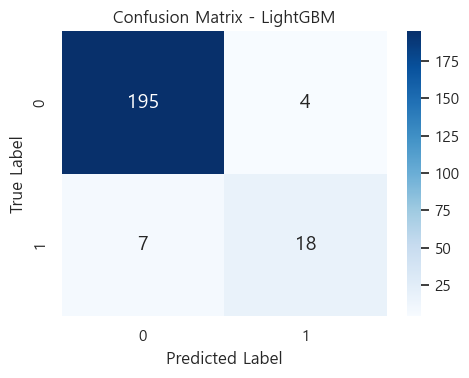


[검증 평가] XGBoost 모델
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       199
           1       0.84      0.84      0.84        25

    accuracy                           0.96       224
   macro avg       0.91      0.91      0.91       224
weighted avg       0.96      0.96      0.96       224



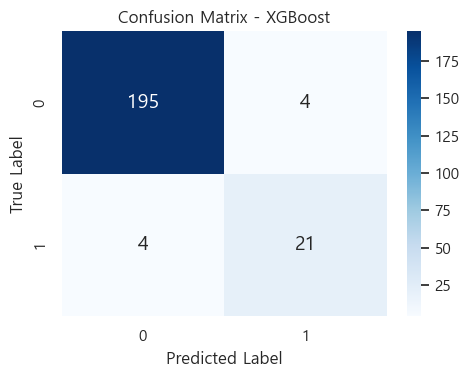

In [41]:
model_names = ["AdaBoost", "GradientBoosting", "LightGBM", "XGBoost"]
model_dir = "./model/A_B"

for name in model_names:
    print(f"\n[검증 평가] {name} 모델")

    model = joblib.load(f"{model_dir}/{name}_gridsearch_model.pkl").best_estimator_
    pred_y = model.predict(test_X)

    # 리포트 출력
    print("Classification Report:")
    print(classification_report(test_y, pred_y, zero_division=0))

    # 혼동 행렬 시각화
    plot_confusion_matrix(test_y, pred_y, model_name=name)

### 예측 확률 시각화


예측 확률 시각화 - AdaBoost


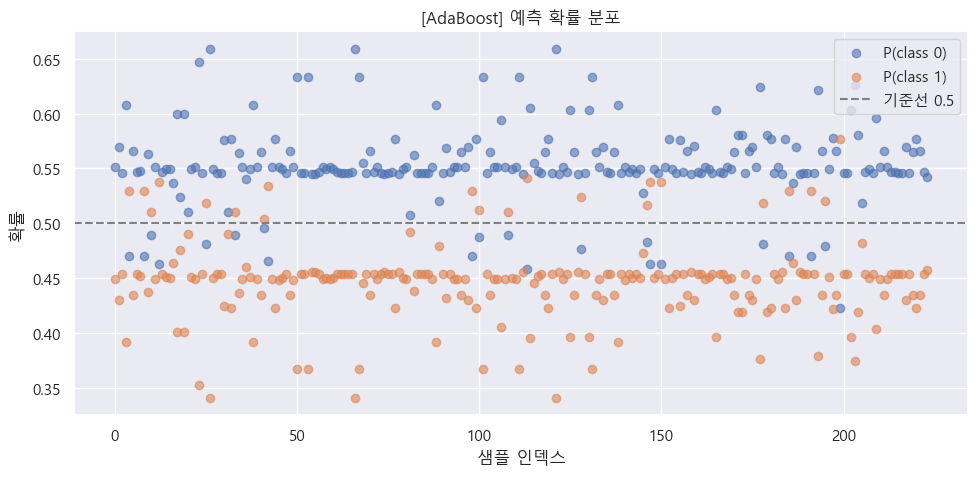


예측 확률 시각화 - GradientBoosting


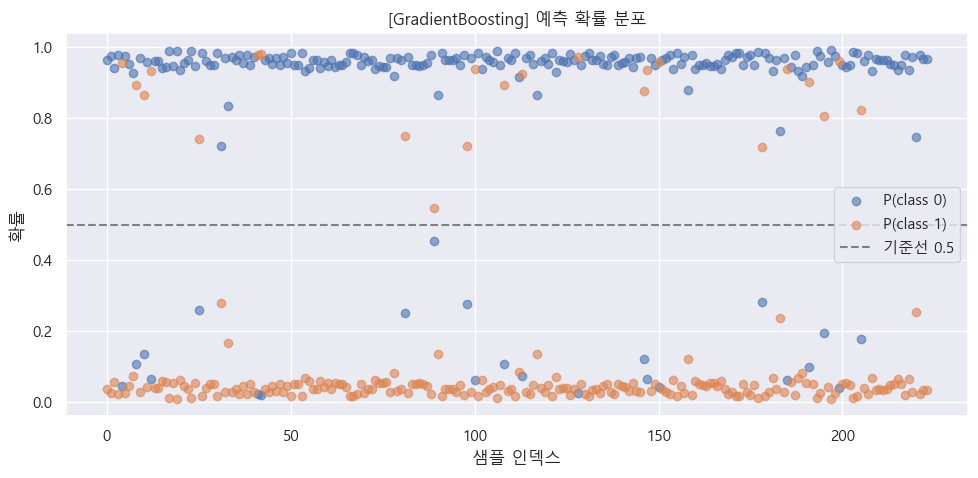


예측 확률 시각화 - LightGBM


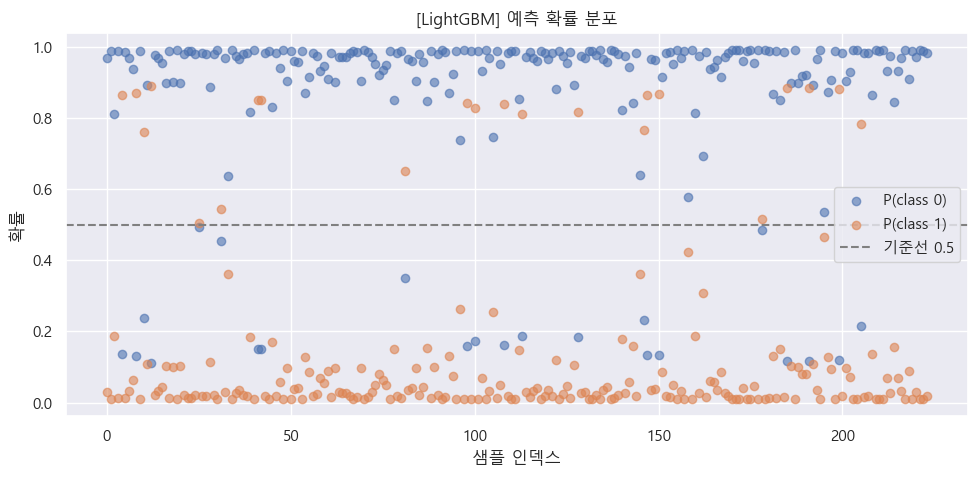


예측 확률 시각화 - XGBoost


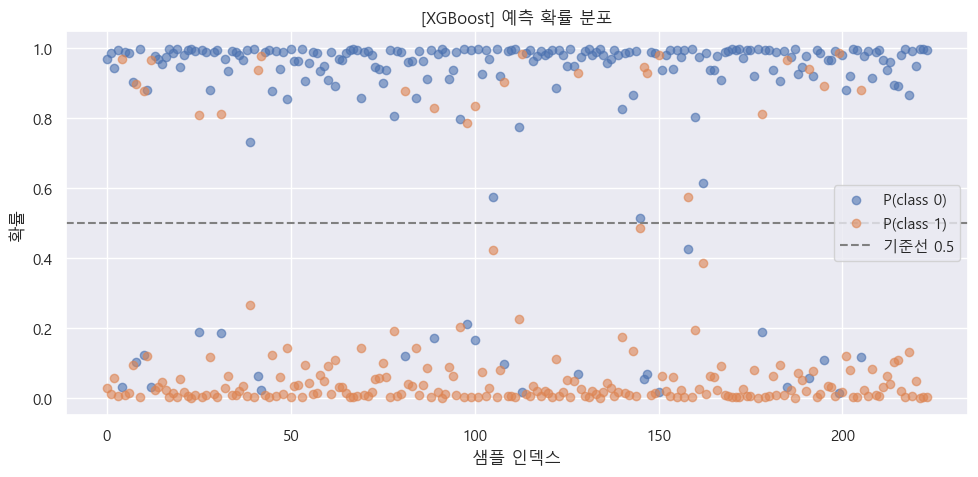

In [42]:
import joblib
import matplotlib.pyplot as plt
import os

# 모델 이름 리스트
model_names = ["AdaBoost", "GradientBoosting", "LightGBM", "XGBoost"]
model_dir = "./model/A_B"

# 예측 확률 시각화
for name in model_names:
    print(f"\n예측 확률 시각화 - {name}")

    # 모델 로드
    model_path = f"{model_dir}/{name}_gridsearch_model.pkl"
    if not os.path.exists(model_path):
        print(f"[경고] 모델 파일 없음: {model_path}")
        continue

    model = joblib.load(model_path).best_estimator_

    # 확률 예측
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(test_X)
        class0_proba = proba[:, 0]
        class1_proba = proba[:, 1]

        # 시각화
        plt.figure(figsize=(10, 5))
        plt.scatter(range(len(class0_proba)), class0_proba, label="P(class 0)", alpha=0.6)
        plt.scatter(range(len(class1_proba)), class1_proba, label="P(class 1)", alpha=0.6)
        plt.axhline(0.5, color='gray', linestyle='--', label='기준선 0.5')
        plt.title(f"[{name}] 예측 확률 분포")
        plt.xlabel("샘플 인덱스")
        plt.ylabel("확률")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"[스킵] {name} 모델은 predict_proba() 미지원")
